# Exploratory Data Analysis (EDA)

## Objective

Analyze the distribution of toxic labels and understand characteristics of toxic comments.

### Questions

- How common is each toxic category?
- Is the dataset balanced?
- Do comments have multiple labels?
- Are toxic comments longer than non-toxic comments?

## 1. Environment setup

Runs on both Google Colab and locally -- detects where it's running and adjusts data paths accordingly.


In [2]:
import os

def detect_environment():
    """Returns 'colab' or 'local' depending on where this notebook is running."""
    try:
        import google.colab
        return "colab"
    except ImportError:
        return "local"

ENV = detect_environment()
print(f"Detected environment: {ENV}")


Detected environment: local


## 2. Import

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

## 3. Load data

Paths are set automatically based on the detected environment:
- **Colab**: mounts your Google Drive and reads from a shared `jigsaw-data/` folder (make sure this folder has been added to your own Drive first).
- **Local**: reads directly from `../data/` relative to this notebook.

In [4]:
if ENV == "colab":
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = "/content/drive/MyDrive/jigsaw-data/"
else:
    DATA_DIR = "../data/"

TRAIN_PATH = DATA_DIR + "train.csv"
TEST_PATH = DATA_DIR + "test.csv"

for name, path in [("train.csv", TRAIN_PATH), ("test.csv", TEST_PATH)]:
    status = "FOUND" if os.path.exists(path) else "MISSING"
    print(f"{status:8s} {name:18s} -> {path}")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)


FOUND    train.csv          -> ../data/train.csv
FOUND    test.csv           -> ../data/test.csv


## 4. Label distribution

### 4.1 Percentage of Toxic Comments (binary vision)

In [5]:
train['toxic'].value_counts(normalize=True)

toxic
0    0.904156
1    0.095844
Name: proportion, dtype: float64

### 4.2 Per-label counts and rates (multi-label view)


In [6]:
labels = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

In [7]:
## count positives
label_counts = train[labels].sum()
print("Number of comments positive for each label:")
print(label_counts)

label_rates = train[labels].mean().sort_values(ascending=False) * 100
print("Percent of comments positive for each label:")
print(label_rates.round(2))

Number of comments positive for each label:
toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64
Percent of comments positive for each label:
toxic            9.58
obscene          5.29
insult           4.94
severe_toxic     1.00
identity_hate    0.88
threat           0.30
dtype: float64


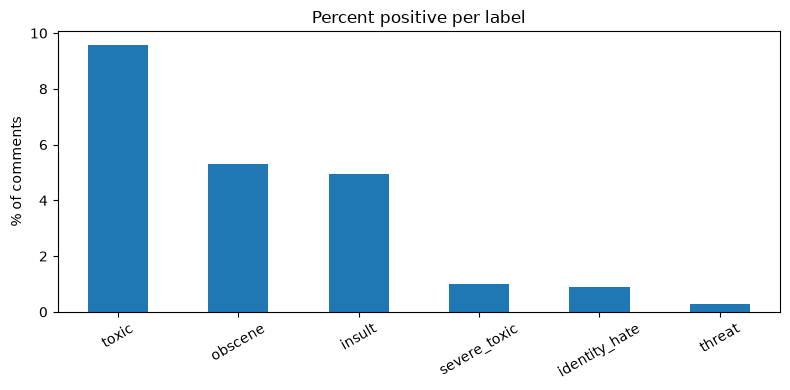

In [8]:
label_rates.plot(kind='bar', figsize=(8, 4), title='Percent positive per label')
plt.ylabel('% of comments')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### 4.3 Label counts as percentage of the full dataset


In [9]:
# percentage of total toxic comments

(label_counts / len(train))*100

toxic            9.584448
severe_toxic     0.999555
obscene          5.294822
threat           0.299553
insult           4.936361
identity_hate    0.880486
dtype: float64

### 4.4 Label Distribution Visualization

Visual comparison of all target categories.

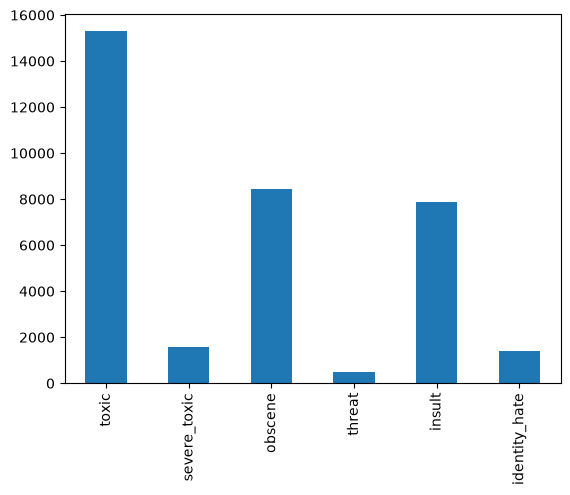

In [10]:
label_counts.plot(kind="bar")
plt.show()

## 5. Reading actual comments

A quick qualitative check before the quantitative analysis below -- what do toxic vs. non-toxic comments actually look like?


### 5.1 Sample of comments labeled `toxic`


In [11]:
train[train["toxic"] == 1]["comment_text"].head()

6          COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK
12    Hey... what is it..\n@ | talk .\nWhat is it......
16    Bye! \n\nDon't look, come or think of comming ...
42    You are gay or antisemmitian? \n\nArchangel WH...
43             FUCK YOUR FILTHY MOTHER IN THE ASS, DRY!
Name: comment_text, dtype: str

### 5.2 Sample of comments labeled `toxic` (full, separate variable)

In [12]:
toxic_comments = train[train['toxic'] == 1]
toxic_comments['comment_text'].head(10)

6          COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK
12    Hey... what is it..\n@ | talk .\nWhat is it......
16    Bye! \n\nDon't look, come or think of comming ...
42    You are gay or antisemmitian? \n\nArchangel WH...
43             FUCK YOUR FILTHY MOTHER IN THE ASS, DRY!
44    I'm Sorry \n\nI'm sorry I screwed around with ...
51    GET FUCKED UP. GET FUCKEEED UP.  GOT A DRINK T...
55    Stupid peace of shit stop deleting my stuff as...
56    =Tony Sidaway is obviously a fistfuckee. He lo...
58    My Band Page's deletion. You thought I was gon...
Name: comment_text, dtype: str

### 5.3 Sample of comments NOT labeled `toxic`, for contrast


In [13]:
non_toxic_comments = train[train["toxic"] == 0]
non_toxic_comments["comment_text"].head(10)

0     Explanation\nWhy the edits made under my usern...
1     D'aww! He matches this background colour I'm s...
2     Hey man, I'm really not trying to edit war. It...
3     "\nMore\nI can't make any real suggestions on ...
4     You, sir, are my hero. Any chance you remember...
5     "\n\nCongratulations from me as well, use the ...
7     Your vandalism to the Matt Shirvington article...
8     Sorry if the word 'nonsense' was offensive to ...
9     alignment on this subject and which are contra...
10    "\nFair use rationale for Image:Wonju.jpg\n\nT...
Name: comment_text, dtype: str

## 6. Multi-label analysis

Investigate whether comments belong to multiple categories at once -- the key question that justifies treating this as multi-label rather than binary.


### 6.1 How many labels does each comment have?


In [14]:
train['num_labels'] = train[labels].sum(axis=1)

Number of comments by how many labels they have:
num_labels
0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64


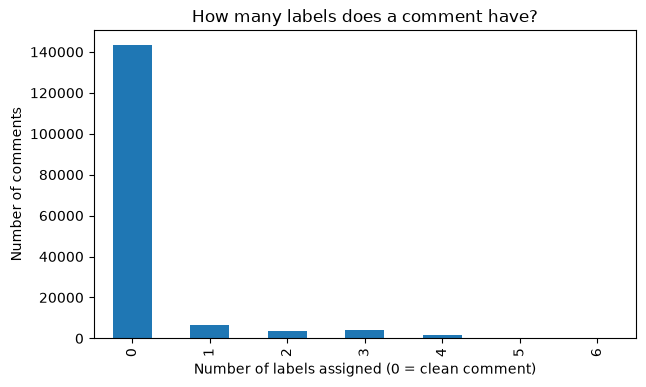

In [15]:
label_count_dist = train['num_labels'].value_counts().sort_index()
print("Number of comments by how many labels they have:")
print(label_count_dist)

label_count_dist.plot(kind='bar', figsize=(7, 4),
                       title='How many labels does a comment have?')
plt.xlabel('Number of labels assigned (0 = clean comment)')
plt.ylabel('Number of comments')
plt.show()


### 6.2 What fraction of labeled comments have more than one label?


In [16]:
# Of comments that have AT LEAST ONE label, what fraction have more than one?
has_any_label = train[train['num_labels'] > 0]
multi_label_pct = (has_any_label['num_labels'] > 1).mean() * 100
print(f"Of comments with at least one label, {multi_label_pct:.1f}% have MORE than one label.")
print("This is the key number that justifies treating this as multi-label, not binary.")


Of comments with at least one label, 60.8% have MORE than one label.
This is the key number that justifies treating this as multi-label, not binary.


## 7. Label co-occurrence

Which labels show up together?


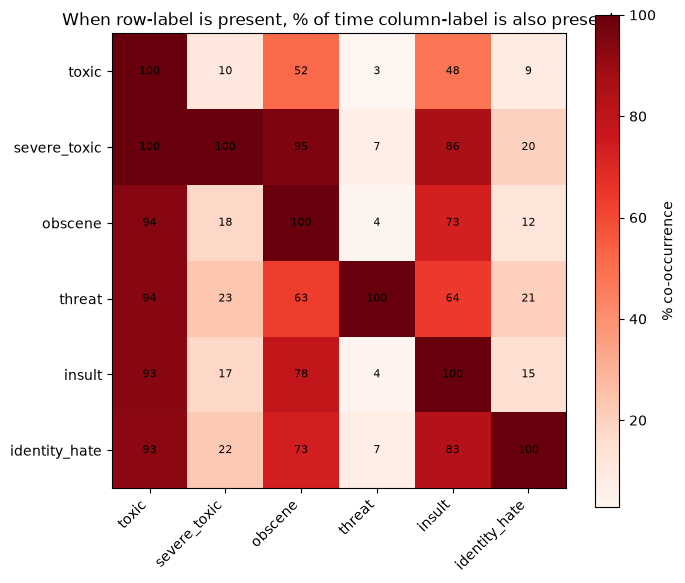

In [17]:
co_occurrence = train[labels].T.dot(train[labels])
# normalize by diagonal (how many times each label appears alone) so values are comparable
co_occurrence_pct = co_occurrence.div(np.diag(co_occurrence), axis=0) * 100

plt.figure(figsize=(7, 6))
plt.imshow(co_occurrence_pct, cmap='Reds')
plt.colorbar(label='% co-occurrence')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.yticks(range(len(labels)), labels)
plt.title('When row-label is present, % of time column-label is also present')
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, f"{co_occurrence_pct.iloc[i, j]:.0f}", ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()


## 8. Comment length analysis

Compare toxic and non-toxic comments based on word count, per label.

In [18]:
if 'comment_len' not in train.columns:
    train['comment_len'] = train['comment_text'].apply(len)
    train['word_count'] = train['comment_text'].apply(lambda x: len(x.split()))

length_by_label = pd.DataFrame({
    label: [
        train.loc[train[label] == 1, 'word_count'].mean(),
        train.loc[train[label] == 0, 'word_count'].mean(),
    ]
    for label in labels
}, index=['label = 1 (mean words)', 'label = 0 (mean words)']).T

length_by_label


,label = 1 (mean words),label = 0 (mean words)
toxic,51.289787,68.967874
severe_toxic,75.620690,67.189250
obscene,49.560540,68.263833
threat,55.165272,67.309907
insult,48.269265,68.260360
identity_hate,52.014235,67.409077


# Conclusions

### Observations

- Toxic comments represent approximately 9.6% of the dataset.
- Threat is the rarest category.
- The dataset is highly imbalanced.
- Many comments belong to multiple categories.
- Toxic comments tend to be shorter than non-toxic comments.

### Next Steps

- Text preprocessing
- Tokenization
- Stopword removal
- TF-IDF feature extraction
- Baseline machine learning model